# HyDE (Hypothetical Document Embedding) 실험

HyDE(Hypothetical Document Embeddings)는 **사용자 질문에 대해 LLM(대형 언어 모델)로 가상의 문서를 먼저 생성하고, 이 문서를 임베딩하여 검색하는 방식**이다.  
기존에는 질문 자체를 임베딩해 유사한 문서를 찾았지만, HyDE는 질문의 맥락과 의도를 더 잘 반영할 수 있는 가상 문서를 생성해 임베딩하고, 이를 벡터 DB에서 비교함으로써 **더 정확한 검색 결과**를 얻을 수 있다.

**핵심 요약**
- 질문 → LLM이 가상 문서 생성 → 임베딩 → 벡터 DB에서 유사도 검색
- 기존 방식보다 **질문의 의미와 맥락을 더 잘 반영**하여 검색 정확도 향상
- RAG 등 다양한 검색·생성 AI 시스템에서 활용 가능
- 단점: LLM 사용으로 **속도가 느려질 수 있음**

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()

os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['PINECONE_API_KEY'] = os.getenv('PINECONE_API_KEY')
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

In [2]:
import pandas as pd

document_df = pd.read_csv('documents.csv')
queries_df = pd.read_csv('queries.csv')

queries_df

,query_id,query_text,relevant_doc_ids
0,Q1,제주도 올레길 트레킹 코스 추천,D1=3;D4=1;D30=1
1,Q2,전주 비빔밥 vs 진주 비빔밥 재료 및 맛 차이,D2=3
2,Q3,걸스데이 대표 히트곡 목록 알려줘,D3=3
3,Q4,훈민정음 창제 배경과 세종대왕의 의의,D4=3
4,Q5,이순신 장군이 명량 해전에서 사용한 전술은 무엇인가?,D5=3
5,Q6,2024년 기후 변화 주요 지표와 한국의 탄소 중립 정책,D6=3;D14=2;D26=1
6,Q7,한국 AI 윤리 이슈와 관련 정책 사례는?,D7=3;D25=2
7,Q8,서울 지하철 환승 시 T-money 사용 방법,D8=3
8,Q9,판소리 춘향가 줄거리와 공연 특징,D9=3
9,Q10,한국 축구 대표팀 2002년 한일 월드컵 4강 진출 이유,D10=3


In [3]:

from rank_bm25 import BM25Okapi
from kiwipiepy import Kiwi

kiwi = Kiwi()

def kiwi_tokenize(doc):
    return [token.form for token in kiwi.tokenize(doc)]
# 문서 내용 토큰화
tokenized_docs = [kiwi_tokenize(doc) for doc in document_df['content']]
bm25 = BM25Okapi(tokenized_docs) # BM25 모델 생성 (토큰화된 문서)
# 질의문을 토큰화해서 BM25로 상위 문서 검색하는 함수
def bm25_search(query, top_k=5):
    query_tokens = kiwi_tokenize(query)      # 검색어 토큰화
    scores = bm25.get_scores(query_tokens) # 각 문서의 BM25 점수 계산

    # 점수 기준 내림차순 정렬한 인덱스
    ranked_idx = sorted(range(len(scores)), key = lambda i: scores[i], reverse=True)
    retrieved_docs = [document_df['doc_id'].iloc[i] for i in ranked_idx[:top_k]]
    return retrieved_docs

bm25_search('제주도 관광 명소')

['D1', 'D2', 'D3', 'D4', 'D5']

In [4]:
from langchain_openai import OpenAIEmbeddings
from langchain_pinecone import PineconeVectorStore

embeddings = OpenAIEmbeddings(model='text-embedding-3-small') # 1536차원 임베딩 모델
# 벡터스토어 연결
vector_store = PineconeVectorStore(
    index_name = 'ir', # 연결할 index명
    embedding = embeddings # 사용할 임베딩 함수 (연결할 인덱스 차원과 임베딩 차원이 같아야함)
)

## Hyde 가상문서 (가설 답변) 생성 체인 구성

In [5]:
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

llm = init_chat_model('gpt-5.6-luna', temperature=0.3)
prompt = PromptTemplate.from_template('''
질문 : {query}

위 질문에 대해서 실제 문서가 아니어도 좋으니, 답변을 생성해주세요.
''')
output_parser = StrOutputParser()

hyde_chain = prompt | llm | output_parser
print(hyde_chain.invoke('제주도 관광 명소'))

제주도는 자연경관과 문화유산이 풍부해 다양한 관광 명소를 즐길 수 있습니다.

### 제주도 대표 관광 명소

- **한라산 국립공원**: 제주도의 중심에 있는 산으로, 성판악·관음사 코스 등 등산로가 유명합니다.
- **성산일출봉**: 유네스코 세계자연유산으로, 정상에서 보는 일출이 특히 아름답습니다.
- **우도**: 제주 동쪽에 위치한 섬으로, 에메랄드빛 바다와 서빈백사, 검멀레해변이 유명합니다.
- **협재해수욕장**: 맑고 푸른 바다와 하얀 모래사장이 아름다운 대표 해변입니다.
- **함덕해수욕장**: 얕고 잔잔한 바다로 가족 여행객에게 인기가 많습니다.
- **만장굴**: 세계적으로도 규모가 큰 용암동굴 중 하나로, 제주 화산 지형을 볼 수 있습니다.
- **주상절리대**: 바닷가 절벽에 육각형 돌기둥이 펼쳐진 독특한 자연경관입니다.
- **천지연폭포**: 서귀포의 대표 폭포로, 주변 산책로와 야경이 아름답습니다.
- **오설록 티 뮤지엄**: 녹차밭과 차 문화를 체험할 수 있는 인기 명소입니다.
- **카멜리아힐**: 계절별 꽃과 정원을 감상하기 좋은 수목원입니다.
- **용머리해안**: 바닷가를 따라 이어진 독특한 암벽 지형과 해안 풍경이 인상적입니다.
- **동문시장**: 흑돼지, 갈치, 한라봉, 오메기떡 등 제주 먹거리를 즐길 수 있는 전통시장입니다.
- **제주민속촌**: 제주 전통 가옥과 생활문화를 살펴볼 수 있는 곳입니다.
- **비자림**: 오래된 비자나무 숲길을 걸으며 조용히 산책하기 좋습니다.
- **사려니숲길**: 삼나무와 편백나무가 우거진 대표적인 힐링 산책 코스입니다.

### 여행 일정 예시

- **제주 동부**: 성산일출봉 → 섭지코지 → 우도 → 만장굴  
- **제주 서부**: 협재해수욕장 → 한림공원 → 오설록 티 뮤지엄 → 용머리해안  
- **제주 중문·서귀포**: 주상절리대 → 천지연폭포 → 중문색달해변 → 카멜리아힐  

방문 전에는 기상 상황과 탐방로·관광지 운영 여부를 확인하는 것이 좋습니다.


### hyde 가상답변을 퀴리별로 생성/저장

In [6]:
import time
from tqdm.auto import tqdm

hyde_pseudo = {} # qid별 가상답변 저장 dict

for idx, row in tqdm(queries_df.iterrows()):
    qid = row['query_id']
    query_text = row['query_text']
    pseudo_answer = hyde_chain.invoke(query_text) # 가상답변 생성
    hyde_pseudo[qid] = pseudo_answer # {qid: pseuo_answer, ...}
    time.sleep(0.5) # API 과호출 방지용 딜레이

hyde_pseudo

0it [00:00, ?it/s]

{'Q1': '제주 올레길은 해안 풍경, 오름, 마을길이 코스마다 달라서 여행 목적에 따라 고르면 좋습니다. 처음 걷는다면 아래 코스를 추천합니다.\n\n## 1. 가장 무난한 첫 코스: 올레 6코스\n- **구간:** 쇠소깍~제주올레 여행자센터\n- **거리:** 약 11km\n- **소요 시간:** 4~5시간\n- **난이도:** 쉬움\n- **특징:** 쇠소깍, 서귀포 해안, 정방폭포 주변, 서귀포 시내\n- **추천 이유:** 비교적 짧고 길이 잘 정비되어 있으며, 식사와 카페를 이용하기 좋습니다.\n\n## 2. 제주다운 바다 풍경: 올레 7코스\n- **구간:** 제주올레 여행자센터~월평 아왜낭목\n- **거리:** 약 17~18km\n- **소요 시간:** 5~7시간\n- **난이도:** 보통\n- **특징:** 외돌개, 범섬 전망, 해안 절벽, 법환포구\n- **추천 이유:** 제주 올레길의 대표 코스로 꼽히며 바다 풍경이 특히 아름답습니다.\n- **주의:** 거리가 긴 편이므로 운동화와 물을 준비하는 것이 좋습니다.\n\n## 3. 성산일출봉을 함께 보고 싶다면: 올레 1코스\n- **구간:** 시흥리~광치기해변\n- **거리:** 약 15km\n- **소요 시간:** 5~6시간\n- **난이도:** 보통\n- **특징:** 말미오름, 알오름, 성산일출봉, 섭지코지 인근 풍경\n- **추천 이유:** 오름과 바다를 함께 즐길 수 있고, 성산일출봉 관광과 연계하기 좋습니다.\n- **팁:** 날씨가 맑은 날 걷는 것이 좋으며, 초반 오름 구간에서 약간의 오르막이 있습니다.\n\n## 4. 산방산과 송악산을 보고 싶다면: 올레 10코스\n- **구간:** 화순금모래해변~하모체육공원\n- **거리:** 약 15~16km\n- **소요 시간:** 5~6시간\n- **난이도:** 보통\n- **특징:** 산방산, 용머리해안 주변, 송악산, 가파도·마라도 전망\n- **추천 이유:** 서남부 제주의 독특한 해안 지형과 넓은 바다 전망을 감상할 수 있습니

In [7]:
import pandas as pd

pd.set_option('display.max_colwidth', None) # 긴 텍스트도 생략 없이 표시

hyde_df = pd.DataFrame({
    'query_id': list(hyde_pseudo.keys()), # qid 리스트
    'query_text': queries_df['query_text'],         # 원본 질문 시리즈
    'pseudo_answer': list(hyde_pseudo.values()) # 가상 질문 리스트
})
hyde_df.head()

,query_id,query_text,pseudo_answer
0,Q1,제주도 올레길 트레킹 코스 추천,"제주 올레길은 해안 풍경, 오름, 마을길이 코스마다 달라서 여행 목적에 따라 고르면 좋습니다. 처음 걷는다면 아래 코스를 추천합니다.\n\n## 1. 가장 무난한 첫 코스: 올레 6코스\n- **구간:** 쇠소깍~제주올레 여행자센터\n- **거리:** 약 11km\n- **소요 시간:** 4~5시간\n- **난이도:** 쉬움\n- **특징:** 쇠소깍, 서귀포 해안, 정방폭포 주변, 서귀포 시내\n- **추천 이유:** 비교적 짧고 길이 잘 정비되어 있으며, 식사와 카페를 이용하기 좋습니다.\n\n## 2. 제주다운 바다 풍경: 올레 7코스\n- **구간:** 제주올레 여행자센터~월평 아왜낭목\n- **거리:** 약 17~18km\n- **소요 시간:** 5~7시간\n- **난이도:** 보통\n- **특징:** 외돌개, 범섬 전망, 해안 절벽, 법환포구\n- **추천 이유:** 제주 올레길의 대표 코스로 꼽히며 바다 풍경이 특히 아름답습니다.\n- **주의:** 거리가 긴 편이므로 운동화와 물을 준비하는 것이 좋습니다.\n\n## 3. 성산일출봉을 함께 보고 싶다면: 올레 1코스\n- **구간:** 시흥리~광치기해변\n- **거리:** 약 15km\n- **소요 시간:** 5~6시간\n- **난이도:** 보통\n- **특징:** 말미오름, 알오름, 성산일출봉, 섭지코지 인근 풍경\n- **추천 이유:** 오름과 바다를 함께 즐길 수 있고, 성산일출봉 관광과 연계하기 좋습니다.\n- **팁:** 날씨가 맑은 날 걷는 것이 좋으며, 초반 오름 구간에서 약간의 오르막이 있습니다.\n\n## 4. 산방산과 송악산을 보고 싶다면: 올레 10코스\n- **구간:** 화순금모래해변~하모체육공원\n- **거리:** 약 15~16km\n- **소요 시간:** 5~6시간\n- **난이도:** 보통\n- **특징:** 산방산, 용머리해안 주변, 송악산, 가파도·마라도 전망\n- **추천 이유:** 서남부 제주의 독특한 해안 지형과 넓은 바다 전망을 감상할 수 있습니다.\n- **주의:** 해안 절벽과 바람이 강한 구간이 있어 기상 상황을 확인해야 합니다.\n\n## 5. 조용한 마을길과 오름을 좋아한다면: 올레 14코스\n- **구간:** 한림항~저지예술인마을\n- **거리:** 약 19km\n- **소요 시간:** 6~7시간\n- **난이도:** 보통\n- **특징:** 협재·금능 인근, 곶자왈, 제주 서부 마을길\n- **추천 이유:** 관광객이 몰리는 해안 명소뿐 아니라 제주 마을과 숲길의 분위기를 느낄 수 있습니다.\n\n## 6. 짧게 걷고 싶다면: 올레 8코스 일부 구간\n- **추천 구간:** 대평포구~중문색달해변 또는 중문 일대\n- **소요 시간:** 2~4시간 정도로 조절 가능\n- **특징:** 주상절리, 중문 해안, 대평리 박수기정 전망\n- **추천 이유:** 전체 코스를 완주하지 않고도 아름다운 해안 풍경을 즐길 수 있습니다.\n\n## 여행 일정별 추천\n\n### 하루만 걷는 경우\n- **6코스:** 가장 편하고 접근성이 좋음\n- **7코스:** 대표적인 제주 해안 풍경\n- **10코스:** 산방산과 송악산 중심의 절경\n\n### 2~3일 걷는 경우\n- **6코스 + 7코스:** 서귀포 중심으로 이동이 편리함\n- **1코스 + 2코스 일부:** 성산과 동부 풍경을 함께 감상\n- **10코스 + 11코스:** 제주 서남부의 바다와 오름을 연계\n\n## 걷기 전 알아두면 좋은 점\n- 올레길은 포장도로, 돌길, 흙길이 섞여 있으므로 **트레킹화나 쿠션 좋은 운동화**가 적합합니다.\n- 제주 날씨는 변덕스러워 **바람막이와 우비**를 준비하는 것이 좋습니다.\n- 코스에 따라 식당과 편의점이 드문 구간이 있으니 **물과 간식**을 챙기세요.\n- 여름에는 햇빛이 강하고 그늘이 적은 구간이 많아 **모자와 자외선 차단제**가 필요합니다.\n- 태풍, 폭우, 강풍 뒤에는 해안 구간이 통제될 수 있으므로 출발 전 **제주올레 공식 홈페이지나 안내센터에서 코스 개방 여부**를 확인하는 것이 안전합니다.\n\n개인적으로 처음 가신다면 **6코스**, 제주 올레길의 대표적인 매력을 느끼고 싶다면 **7코스**, 가장 인상적인 풍경을 원한다면 **10코스**를 추천합니다."
1,Q2,전주 비빔밥 vs 진주 비빔밥 재료 및 맛 차이,"전주비빔밥과 진주비빔밥은 모두 여러 가지 나물과 고명을 밥에 비벼 먹는 음식이지만, **밥을 짓는 방식과 고명 구성, 곁들이는 국물, 맛의 방향**에서 차이가 있습니다. 다만 음식점과 가정에 따라 조리법은 달라질 수 있습니다.\n\n| 구분 | 전주비빔밥 | 진주비빔밥 |\n|---|---|---|\n| 대표적 특징 | 콩나물과 다양한 나물, 육회가 어우러진 화려한 비빔밥 | ‘칠보화반’ 또는 ‘꽃밥’이라 불리며 여러 색의 나물과 육회를 올림 |\n| 밥 | 쇠고기 육수나 다시마 육수로 밥을 짓는 경우가 많음 | 비교적 담백하게 지은 밥을 사용하는 경우가 많음 |\n| 주요 재료 | 콩나물, 고사리, 도라지, 시금치·취나물 등 각종 나물, 육회, 달걀, 김, 참기름, 고추장 | 숙주나물, 고사리, 도라지, 시금치 등 여러 나물, 육회, 달걀, 참기름, 고추장 |\n| 고기 | 육회를 올리는 형태가 대표적이지만 불고기나 익힌 쇠고기를 쓰기도 함 | 육회를 중요한 고명으로 사용하는 전통이 강함 |\n| 곁들임 | 콩나물국이 흔함 | 선지국이나 쇠고기국을 곁들이는 경우가 많음 |\n| 맛 | 고추장과 참기름의 풍미가 비교적 진하고 감칠맛이 풍부함 | 나물의 향과 담백함이 두드러지며 육회의 고소함이 강조됨 |\n\n## 1. 전주비빔밥의 재료와 맛\n\n전주비빔밥은 보통 다음과 같은 재료를 사용합니다.\n\n- 밥\n- 콩나물\n- 고사리\n- 도라지\n- 시금치나 취나물\n- 무나물\n- 표고버섯\n- 육회 또는 쇠고기\n- 달걀\n- 김\n- 참기름\n- 고추장\n\n전주비빔밥의 특징 중 하나는 **콩나물**입니다. 전주 지역의 콩나물 음식 문화와 연결되어 있으며, 콩나물국을 함께 내는 경우도 많습니다. 밥을 쇠고기 육수에 지어 밥 자체에 은은한 감칠맛을 더하기도 합니다.\n\n맛은 여러 나물의 향과 고추장의 매콤함, 참기름의 고소함이 조화를 이루며, 전체적으로 **풍성하고 진한 맛**에 가깝습니다. 육회가 들어가면 부드럽고 고소한 맛이 더해집니다.\n\n## 2. 진주비빔밥의 재료와 맛\n\n진주비빔밥은 전통적으로 **칠보화반**이라고도 불립니다. 여러 가지 나물을 색깔별로 보기 좋게 올린다는 의미가 담겨 있습니다.\n\n주로 사용하는 재료는 다음과 같습니다.\n\n- 밥\n- 숙주나물\n- 고사리\n- 도라지\n- 시금치 등 푸른 나물\n- 무나물\n- 육회\n- 달걀\n- 참기름\n- 고추장\n\n진주비빔밥은 특히 **숙주나물과 육회**가 중요한 특징으로 언급됩니다. 음식점에 따라 해산물이나 조개류를 고명으로 더하는 경우도 있지만, 모든 진주비빔밥에 공통적으로 들어가는 것은 아닙니다.\n\n전주비빔밥에 비해 밥이나 양념의 맛이 상대적으로 담백하게 느껴질 수 있으며, 나물의 식감과 향, 육회의 고소하고 부드러운 맛이 잘 드러나는 편입니다. 또한 **선지국이나 쇠고기국**을 함께 내는 경우가 있어, 비빔밥과 국물을 함께 먹는 구성이 특징적입니다.\n\n## 맛의 차이를 간단히 말하면\n\n- **전주비빔밥**: 콩나물과 육수 밥, 고추장, 참기름의 조화가 강한 **진하고 감칠맛 있는 맛**\n- **진주비빔밥**: 다양한 나물과 육회의 풍미가 중심인 **담백하고 고소하며 나물 향이 살아 있는 맛**\n\n다만 오늘날에는 두 지역의 비빔밥 모두 육회, 달걀, 여러 나물, 고추장을 함께 사용하기 때문에 실제 음식점에서는 차이가 크게 느껴지지 않을 수도 있습니다. 전통적인 차이는 재료 하나보다는 **전주식은 콩나물과 육수 밥 중심, 진주식은 칠보 나물 구성과 육회·국물 조합 중심**이라고 이해하면 쉽습니다."
2,Q3,걸스데이 대표 히트곡 목록 알려줘,"걸스데이(Girl’s Day)의 대표적

### HyDE(가상답변) 기반 Dense 검색 결과 수집 ([doc_id])

In [8]:
hyde_results = {} # qid별 HyDE 검색 결과([doc_id])
for idx, row in hyde_df.iterrows():
    qid = row['query_id']
    query_text = row['query_text']
    pseudo_answer = row['pseudo_answer']
    docs = vector_store.similarity_search(pseudo_answer, k=5) # 가상답변으로 top-5 벡터 검색
    hyde_results[qid] = [doc.metadata['doc_id'] for doc in docs]

hyde_results

{'Q1': ['D12', 'D1', 'D11', 'D8', 'D13'],
 'Q2': ['D13', 'D2', 'D16', 'D12', 'D24'],
 'Q3': ['D3', 'D15', 'D17', 'D18', 'D9'],
 'Q4': ['D4', 'D18', 'D15', 'D28', 'D16'],
 'Q5': ['D5', 'D23', 'D11', 'D6', 'D8'],
 'Q6': ['D11', 'D6', 'D25', 'D14', 'D16'],
 'Q7': ['D25', 'D7', 'D14', 'D29', 'D11'],
 'Q8': ['D8', 'D30', 'D18', 'D11', 'D12'],
 'Q9': ['D9', 'D15', 'D16', 'D29', 'D19'],
 'Q10': ['D10', 'D25', 'D15', 'D1', 'D11'],
 'Q11': ['D11', 'D29', 'D28', 'D18', 'D12'],
 'Q12': ['D12', 'D8', 'D1', 'D11', 'D13'],
 'Q13': ['D13', 'D2', 'D11', 'D28', 'D16'],
 'Q14': ['D14', 'D7', 'D26', 'D25', 'D29'],
 'Q15': ['D15', 'D9', 'D19', 'D2', 'D7'],
 'Q16': ['D16', 'D2', 'D9', 'D24', 'D23'],
 'Q17': ['D17', 'D29', 'D28', 'D13', 'D11'],
 'Q18': ['D18', 'D20', 'D4', 'D21', 'D28'],
 'Q19': ['D19', 'D11', 'D28', 'D29', 'D23'],
 'Q20': ['D20', 'D19', 'D7', 'D29', 'D22'],
 'Q21': ['D21', 'D28', 'D29', 'D18', 'D30'],
 'Q22': ['D22', 'D20', 'D23', 'D24', 'D19'],
 'Q23': ['D23', 'D24', 'D20', 'D22', 'D19'],

In [9]:
bm25_results = {}  # qid별 BM25 검색 결과 저장 dict
for idx, row in queries_df.iterrows():
    qid = row['query_id'] # 쿼리 ID 추출
    query_text = row['query_text'] # 쿼리 문장
    bm25_results[qid] = bm25_search(query_text, top_k=5) # {qid: query_text와 가장 가까운 5개의 doc_id}
bm25_results

{'Q1': ['D1', 'D2', 'D3', 'D4', 'D5'],
 'Q2': ['D13', 'D2', 'D1', 'D3', 'D4'],
 'Q3': ['D2', 'D21', 'D14', 'D11', 'D28'],
 'Q4': ['D4', 'D9', 'D1', 'D30', 'D5'],
 'Q5': ['D5', 'D18', 'D19', 'D23', 'D15'],
 'Q6': ['D6', 'D27', 'D17', 'D25', 'D3'],
 'Q7': ['D27', 'D25', 'D7', 'D14', 'D9'],
 'Q8': ['D8', 'D18', 'D30', 'D12', 'D29'],
 'Q9': ['D9', 'D27', 'D1', 'D2', 'D3'],
 'Q10': ['D10', 'D3', 'D17', 'D9', 'D25'],
 'Q11': ['D11', 'D4', 'D14', 'D28', 'D26'],
 'Q12': ['D12', 'D8', 'D9', 'D27', 'D5'],
 'Q13': ['D13', 'D14', 'D26', 'D2', 'D3'],
 'Q14': ['D14', 'D7', 'D25', 'D27', 'D26'],
 'Q15': ['D9', 'D15', 'D26', 'D14', 'D1'],
 'Q16': ['D16', 'D15', 'D9', 'D29', 'D8'],
 'Q17': ['D17', 'D25', 'D6', 'D3', 'D10'],
 'Q18': ['D18', 'D4', 'D28', 'D5', 'D7'],
 'Q19': ['D19', 'D18', 'D14', 'D24', 'D29'],
 'Q20': ['D20', 'D27', 'D10', 'D3', 'D4'],
 'Q21': ['D21', 'D19', 'D25', 'D2', 'D11'],
 'Q22': ['D22', 'D23', 'D19', 'D18', 'D24'],
 'Q23': ['D23', 'D26', 'D24', 'D22', 'D19'],
 'Q24': ['D24', 'D2

In [10]:
# Vector Store 검색 결과를 쿼리별로 수집
dense_results = {}  # qid별 Dense 검색 결과 저장 dict
for idx, row in queries_df.iterrows():
    qid = row['query_id'] # 쿼리 ID 추출
    query_text = row['query_text'] # 쿼리 문장
    # {qid: query_text와 가장 가까운 5개의 doc_id}
    docs = vector_store.similarity_search(query_text, k=5) # 벡터 유사도 기준 top-5 문서 검색
    dense_results[qid] = [doc.metadata['doc_id'] for doc in docs] # doc_id만 리스트로 저장
dense_results

{'Q1': ['D12', 'D1', 'D13', 'D8', 'D9'],
 'Q2': ['D13', 'D2', 'D12', 'D24', 'D8'],
 'Q3': ['D3', 'D17', 'D15', 'D18', 'D29'],
 'Q4': ['D4', 'D16', 'D26', 'D15', 'D18'],
 'Q5': ['D5', 'D23', 'D7', 'D14', 'D26'],
 'Q6': ['D6', 'D14', 'D25', 'D13', 'D18'],
 'Q7': ['D25', 'D7', 'D29', 'D14', 'D17'],
 'Q8': ['D8', 'D12', 'D18', 'D30', 'D17'],
 'Q9': ['D9', 'D3', 'D19', 'D15', 'D12'],
 'Q10': ['D10', 'D25', 'D4', 'D15', 'D3'],
 'Q11': ['D11', 'D18', 'D19', 'D12', 'D23'],
 'Q12': ['D12', 'D8', 'D1', 'D13', 'D9'],
 'Q13': ['D13', 'D2', 'D19', 'D24', 'D23'],
 'Q14': ['D14', 'D6', 'D26', 'D25', 'D7'],
 'Q15': ['D15', 'D14', 'D11', 'D9', 'D26'],
 'Q16': ['D16', 'D23', 'D9', 'D19', 'D22'],
 'Q17': ['D17', 'D25', 'D15', 'D10', 'D3'],
 'Q18': ['D18', 'D4', 'D27', 'D14', 'D26'],
 'Q19': ['D19', 'D18', 'D27', 'D24', 'D28'],
 'Q20': ['D20', 'D19', 'D22', 'D24', 'D18'],
 'Q21': ['D21', 'D23', 'D18', 'D24', 'D30'],
 'Q22': ['D22', 'D23', 'D24', 'D19', 'D11'],
 'Q23': ['D23', 'D24', 'D22', 'D20', 'D19'],


In [11]:
import numpy as np

def parse_relevant(relevant_str) -> dict[str, int]:
    '''
    참조문서 답안 문자열을 dict로 파싱하는 함수

    relevant_str = "D1=3;D4=1;D30=1" -> {'D1': 3, 'D4': 1, 'D30': 1}
    '''
    pairs = relevant_str.split(';')
    rel_dict = {}

    for pair in pairs:
        doc_id, grade = pair.split('=')
        rel_dict[doc_id] = int(grade)
    return rel_dict
# 예측 결과와 실제 정답을 비교해서 평가지표를 계산하는 함수
def compute_metrics(predicted, relevant_dict, k=5) -> tuple[float, float, float, float]:
    # Precision@k
    hits = sum([1 for doc in predicted[:k] if doc in relevant_dict]) # top-k 적중 개수
    precision = hits / k # 정밀도 = 맞춘갯수 / 전체갯수
    # Recall@k
    total_relevant = len(relevant_dict) # 전체 관련 문서 수
    recall = hits / total_relevant if total_relevant > 0 else 0 # 재현율 = 관련 문서 맞춘 수

    # MRR 예측치 중 첫 관련문서 순위 점수
    rr = 0 # 관련 문서 수
    # 전체 랭킹에서 첫번째 적중된 것을 찾음
    for idx, doc in enumerate(predicted):
        if doc in relevant_dict:
            rr = 1 / (idx + 1) # 첫 적중 순위 역수
            break # 첫 번째 적중 rr 반영 후 break

    # AP (MAP를 위한 사전 계산)
    num_correct = 0 # 현재까지의 적중 횟수
    precisions = [] # 적중시의 precision
    for idx, doc in enumerate(predicted[:k]): # top-k 범위에서 
        if doc in relevant_dict:
            num_correct += 1
            precisions.append(num_correct / (idx + 1)) # 현재 시점의 precision 기록
    ap = np.mean(precisions) if precisions else 0 # precision 평균치 사용, 없으면 0

    return precision, recall, rr, ap
# 여러 쿼리에 대한 평균 성능지표 계산하는 함수
def evaluate_all(method_results, queries_df, k=5):
    prec_list, rec_list, rr_list, ap_list = [], [], [], []

    for idx, row in queries_df.iterrows():
        qid = row['query_id']
        relevant_dict = parse_relevant(row['relevant_doc_ids']) # 정답 dict 파싱
        predicted = method_results[qid] # 해당 쿼리의 에측 랭킹
        p, r, rr, ap = compute_metrics(predicted, relevant_dict, k) # 지표 계산
        prec_list.append(p)
        rec_list.append(r)
        rr_list.append(rr)
        ap_list.append(ap) 

    return {
        'P@k': np.mean(prec_list), # 쿼리 평균 Precision@k
        'R@k': np.mean(rec_list),  # 쿼리 평균 Recall@k
        'MRR': np.mean(rr_list),   # 쿼리 평균 MRR
        'MAP': np.mean(ap_list),   # 쿼리 평균 MAP
    }

In [12]:
# BM25 / Dense 결과로 P@5, R@5, MRR, MAP 계산
bm25_metrics = evaluate_all(bm25_results, queries_df, k=5)
dense_metrics = evaluate_all(dense_results, queries_df, k=5)
hyde_metrics = evaluate_all(hyde_results, queries_df, k=5)

In [13]:
metrics_df = pd.DataFrame({
    'Metrics': ['P@5', 'R@5', 'MRR', 'MAP'],
    'BM25': [bm25_metrics['P@k'], bm25_metrics['R@k'], bm25_metrics['MRR'], bm25_metrics['MAP']],
    'Dense': [dense_metrics['P@k'], dense_metrics['R@k'], dense_metrics['MRR'], dense_metrics['MAP']],
    'HyDE': [hyde_metrics['P@k'], hyde_metrics['R@k'], hyde_metrics['MRR'], hyde_metrics['MAP']]
})
metrics_df

,Metrics,BM25,Dense,HyDE
0,P@5,0.233333,0.246667,0.253333
1,R@5,0.838889,0.888889,0.905556
2,MRR,0.900000,0.950000,0.950000
3,MAP,0.874444,0.920556,0.923333


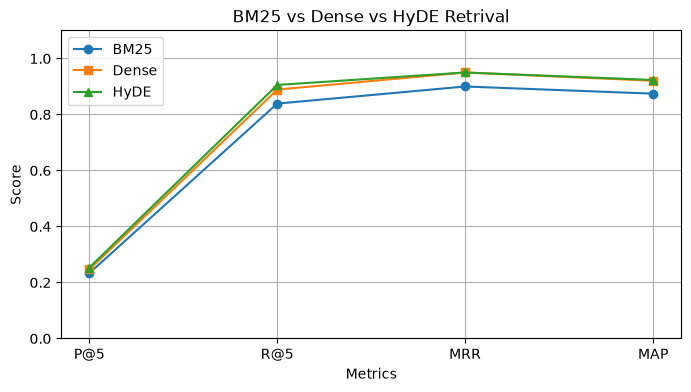

In [14]:
import matplotlib.pyplot as plt

metrics = ['P@5', 'R@5', 'MRR', 'MAP']
bm25_vals = [bm25_metrics['P@k'], bm25_metrics['R@k'], bm25_metrics['MRR'], bm25_metrics['MAP']]
dense_vals = [dense_metrics['P@k'], dense_metrics['R@k'], dense_metrics['MRR'], dense_metrics['MAP']]
hyde_vals = [hyde_metrics['P@k'], hyde_metrics['R@k'], hyde_metrics['MRR'], hyde_metrics['MAP']]

x = range(len(metrics))

plt.figure(figsize=(8, 4))
plt.plot(x, bm25_vals, marker='o', label='BM25')
plt.plot(x, dense_vals, marker='s', label='Dense')
plt.plot(x, hyde_vals, marker='^', label='HyDE')
plt.xticks(x, metrics)
plt.ylim(0, 1.1)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('BM25 vs Dense vs HyDE Retrival')
plt.legend()
plt.grid()
plt.show()

##### HyDE의 역할과 효과
- HyDE는 쿼리를 “의미가 풍부한 가상문서”로 확장
- Dense가 이미 강력한 경우:
    - 성능을 보완하거나 유지
    - 항상 큰 폭의 개선을 보장하지는 않음
- 하지만 쿼리가 짧거나 모호한 경우, HyDE의 효과는 더욱 커질 가능성 있음

- Dense Retrieval은 의미 기반 검색의 기본 선택지
- HyDE는 다음 상황에서 특히 유용:
    - 짧고 추상적인 쿼리
    - 질문형 질의
    - Recall 개선이 중요한 경우
- 실서비스에서는: Dense + (HyDE / BM25 / Rerank) 조합이 가장 현실적인 접근

Dense - VectorDB에서 검색 / 문맥의 의미 유사도 검색  
HyDE - VecotrDB 검색 쿼리를 LLM 요청 수정하는 경우  
제주도 여행 -> 제주도 여행에 대한 쿼리  
BM25 - 문맥상 자주 나오는 단어로 검색 (형태소상)  
Rerank - 두가지 기법을 합쳐서 다시 랭킹  